In [1]:
import pandas as pd
import numpy as np
from pandas import read_csv


In [2]:
#read the csv file and browser the dataset
dataset=read_csv("Assign_regression_data.csv")
print(len(dataset))
print(type(dataset))
print(dataset.head())
print(dataset.describe())

3895
<class 'pandas.core.frame.DataFrame'>
    composition  Eg (eV)  en_min  en_max  en_weighted_mean  en_spread  \
0  Hg0.7Cd0.3Te     0.35     NaN     NaN               NaN        NaN   
1          CuBr     3.08    1.90    2.96           2.43000       1.06   
2           LuP     1.30    1.27    2.19           1.73000       0.92   
3      Cu3SbSe4     0.40    1.90    2.55           2.24375       0.65   
4           ZnO     3.44    1.65    3.44           2.54500       1.79   

   en_weighted_std  
0              NaN  
1         0.530000  
2         0.460000  
3         0.309675  
4         0.895000  
           Eg (eV)       en_min       en_max  en_weighted_mean    en_spread  \
count  3895.000000  3346.000000  3346.000000       3346.000000  3346.000000   
mean      2.042470     1.462935     2.667074          2.217598     1.204139   
std       1.501525     0.474257     0.471886          0.349588     0.711756   
min       0.020000     0.790000     1.360000          1.097500     0.000000 

In [3]:
#check for missing values
dataset.isnull().sum()

composition           0
Eg (eV)               0
en_min              549
en_max              549
en_weighted_mean    549
en_spread           549
en_weighted_std     549
dtype: int64

In [4]:
#drop missing values
df=dataset.dropna()
print(len(df))

3346


In [5]:

df1=df.copy()
df1=df1[["composition","Eg (eV)"]].rename(columns={"composition":"formula","Eg (eV)":"target"})
print(df1.head())

    formula  target
1      CuBr    3.08
2       LuP    1.30
3  Cu3SbSe4    0.40
4       ZnO    3.44
5     PtSb2    0.08


In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from CBFV import composition
X,y,formulae,skipped=composition.generate_features(df1,elem_prop="mat2vec")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# y_scaled = scaler.fit_transform(y.values.reshape(-1, 1))
y_scaled = y.values

Processing Input Data:   0%|          | 0/3346 [00:00<?, ?it/s]

Processing Input Data: 100%|██████████| 3346/3346 [00:00<00:00, 10781.73it/s]


	Featurizing Compositions...


Assigning Features...: 100%|██████████| 3346/3346 [00:00<00:00, 4648.13it/s]


	Creating Pandas Objects...


In [23]:
#split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# evaluate the model
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')


In [24]:

print(f"MSE in test set: {mse:.4f}")
print(f"R² in test set: {r2:.4f}")
print(f"cross-validated R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


MSE in test set: 0.8199
R² in test set: 0.6230
cross-validated R²: 0.6793 ± 0.0625


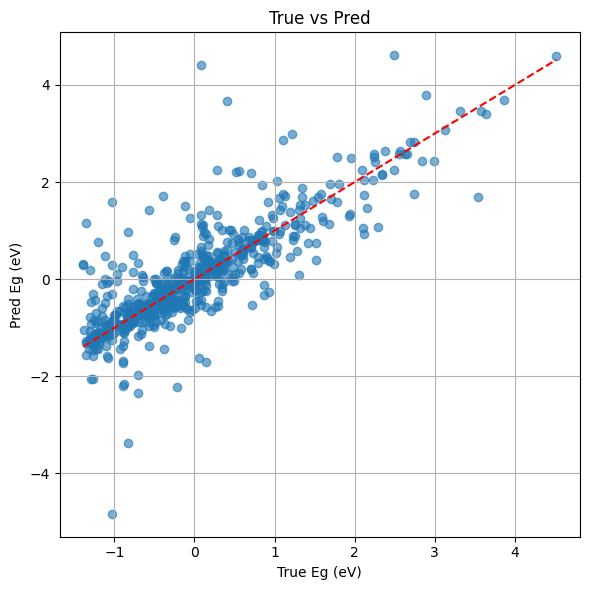

In [21]:
from matplotlib import pyplot as plt
# true vs predicted plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("True Eg (eV)")
plt.ylabel("Pred Eg (eV)")
plt.title("True vs Pred")
plt.grid(True)
plt.tight_layout()
plt.show()


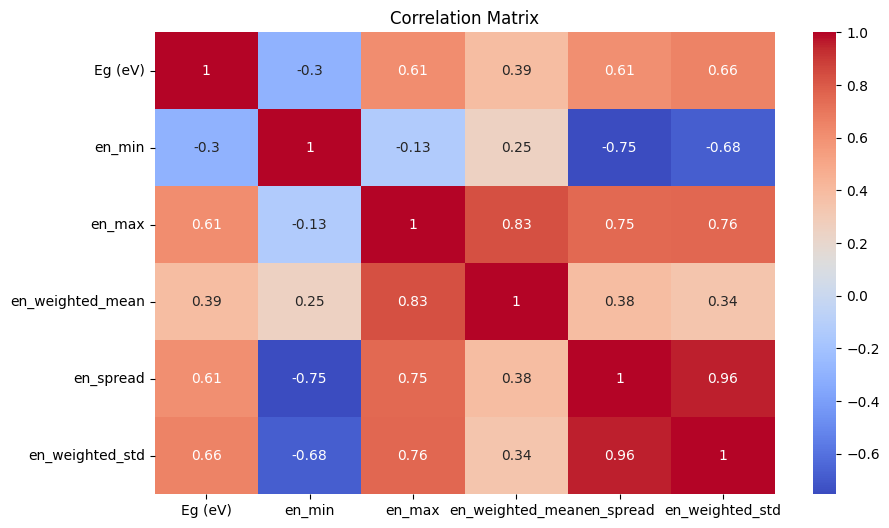

In [10]:
#if we drop the composition column and plot the correlation matrix
from matplotlib import pyplot as plt
import seaborn as sns
df_drop_composition=df.drop(columns=['composition'])
plt.figure(figsize=(10, 6))
sns.heatmap(df_drop_composition.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()
#in the first column(row), the value is the correlation of the target(Eg) with other features.
#cause the the en_max, en_spread,en_weighted_std, they have high correlation(0.61, 0.61 and 0.66 respectively) with the target(Eg), we can use these three features to do the regression.

In [11]:
df2=df.copy()
df2=df2[["composition","en_max","en_spread","en_weighted_std","Eg (eV)"]].rename(
    columns={"composition":"formula","Eg (eV)":"target","en_max":"feature1","en_spread":"feature2","en_weighted_std":"feature3"}
    )
print(df2.head())

    formula  feature1  feature2  feature3  target
1      CuBr      2.96      1.06  0.530000    3.08
2       LuP      2.19      0.92  0.460000    1.30
3  Cu3SbSe4      2.55      0.65  0.309675    0.40
4       ZnO      3.44      1.79  0.895000    3.44
5     PtSb2      2.28      0.23  0.108423    0.08


In [12]:
X2,y2,formulae2,skipped2=composition.generate_features(df2,elem_prop="magpie")
print(X2.shape)
print(y2.shape)
import pandas as pd
X2 = pd.concat([X2.reset_index(drop=True), df2[["feature1", "feature2", "feature3"]].reset_index(drop=True)], axis=1)
scaler2 = StandardScaler()
X_scaled2 = scaler2.fit_transform(X2)
# y_scaled2 = scaler2.fit_transform(y2.values.reshape(-1, 1))
y_scaled2 = y2.values
print(X2.shape)
print(y2.shape)

Processing Input Data:   0%|          | 0/3346 [00:00<?, ?it/s]

Processing Input Data: 100%|██████████| 3346/3346 [00:00<00:00, 14424.36it/s]


	Featurizing Compositions...


Assigning Features...: 100%|██████████| 3346/3346 [00:00<00:00, 6069.62it/s]


	Creating Pandas Objects...
(3346, 132)
(3346,)
(3346, 135)
(3346,)


In [13]:
#split the data into training and testing sets
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_scaled2, y_scaled2, test_size=0.2, random_state=42)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

# evaluate the model
y_pred2 = model2.predict(X_test2)
mse2 = mean_squared_error(y_test2, y_pred2)
r2_2 = r2_score(y_test2, y_pred2)
cv_scores2 = cross_val_score(model2, X_scaled2, y_scaled2, cv=5, scoring='r2')

print(f"MSE in test set: {mse2:.4f}")
print(f"R² in test set: {r2_2:.4f}")
print(f"cross-validated R²: {cv_scores2.mean():.4f} ± {cv_scores2.std():.4f}")


MSE in test set: 0.6276
R² in test set: 0.7115
cross-validated R²: -2910365202.2977 ± 5820730405.9710


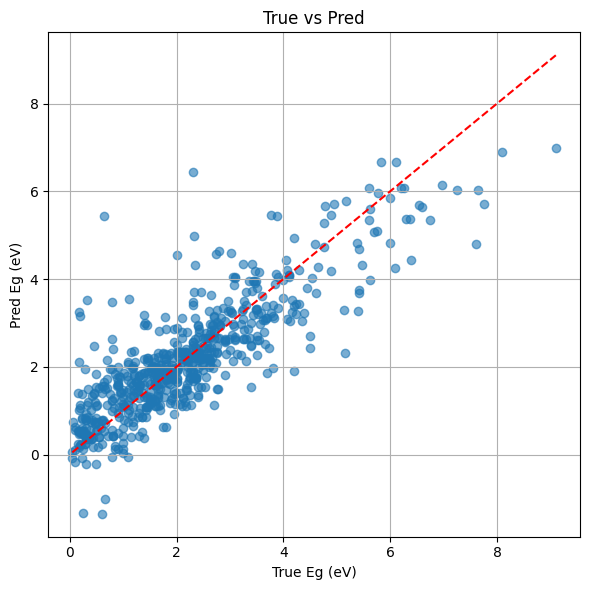

In [14]:
from matplotlib import pyplot as plt
# true vs predicted plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test2, y_pred2, alpha=0.6)
plt.plot([y_test2.min(), y_test2.max()], [y_test2.min(), y_test2.max()], 'r--')
plt.xlabel("True Eg (eV)")
plt.ylabel("Pred Eg (eV)")
plt.title("True vs Pred")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
git config --global user.name “gitname”
git config --global user.email “git邮箱”